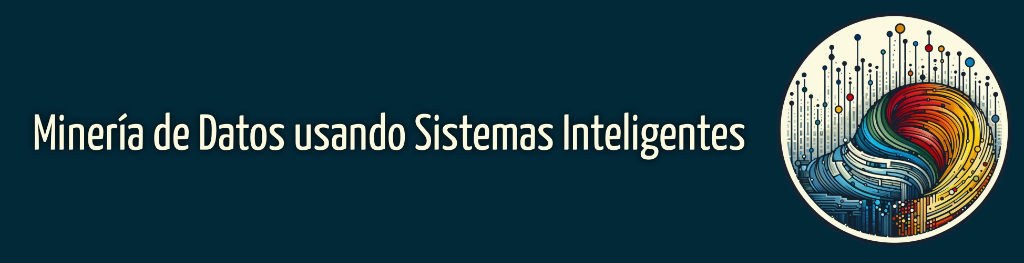



# PRACTICA 4

# ÁRBOLES DE CLASIFICACIÓN

***Material de Lectura: Capítulo 11 del Libro Introducción a la Minería de Datos de Hernández Orallo***

***Ejercicios a entregar: 5a, 5c, 7 completo***

**Para resolver los ejercicios en código, utilizar la librería [sklearn_nominal](https://github.com/facundoq/sklearn_nominal); en particular, la clase TreeClassifier. Recuerde que:**

-   **Un árbol ID3 no realiza poda, usa como criterio la ganancia de información, y solo utiliza atributos nominales.**

-   **Un árbol C4.5 utiliza poda, usa como criterio *gain ratio*, y genera discretizaciones automáticas de los atributos numéricos buscando umbrales de discretización binaria óptimos.**

In [1]:
#HELPER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import math
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


try:
    import sklearn_nominal
except ImportError:
    print("Package not found. Installing...")
    %pip install sklearn_nominal
    import sklearn_nominal
    print("Package installed and imported.")
base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"



In [2]:
#HELPER
df_pers = pd.read_excel(base_url + "personajes.xlsx")
df_work_tr = pd.read_csv(base_url + "trabajos_ej4_train.csv")
df_work_ts = pd.read_csv(base_url + "trabajos_ej4_test.csv")
df_work5 = pd.read_excel(base_url + "trabajos_ej5.xlsx")
df_db_tr = pd.read_excel(base_url + "diabetes_nominal_train.xlsx")
df_db_ts = pd.read_excel(base_url + "diabetes_nominal_test.xlsx")

df_pokemon = pd.read_csv(base_url+"pokemon_combats_attributes.csv")


# 1. Concepto de entropía

 Dado un conjunto de datos con 3 clases (A, B y C), la siguiente tabla presenta distintas distribuciones de ejemplos para cada clase. Ordene de menor a mayor las distribuciones de *a, b, c, d, e y f* en términos de su **Entropía**. Intente primero hacer este ejercicio sin realizar cálculos. Luego, verifíque el resultado numéricamente.

| | P(A) | P(B) | P(C) | Entropía |
| --- | --- | --- | --- | --- |
| a | 0.9 | 0.1 | 0 |  |
| b | 0.4 | 0.6 | 0 |  |
| c | 0.6 | 0 | 0.4 |  |
| d | 1 | 0 | 0 | |
| e | 0.33 | 0.33 | 0.33 |  |
| f | 0 | 1 | 0 |  |


# 2. Cálculo de entropía


En base al conjunto de datos del archivo **personajes.xlsx**:

a. Calcule la proporción de ejemplos de cada clase.

| P(A) | P(B) | P(C) |
| --- | --- | --- |
| ? |?  |? |

b. En base a la distribución de clases del punto a), calcule la **Entropía** total E del conjunto de datos, es decir, el nivel de entropía base sin considerar ningún atributo:

| Entropía(E) |
| --- |
| ? |


In [3]:
#HELPER
df = pd.read_excel('https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/personajes.xlsx')
print(df)


  Voluntad Inteligencia     Alineamiento  Nivel Clase
0   Fuerte         Alta  Caótico Neutral      3     A
1   Normal         Alta      Legal Bueno      4     B
2   Fuerte         Alta    Legal Malvado      5     A
3    Débil         Baja    Neutral Bueno      1     C
4    Débil         Alta      Legal Bueno      2     B
5   Fuerte         Alta  Neutral Neutral      3     A
6   Normal         Baja  Caótico Neutral      3     C
7   Fuerte         Alta  Caótico Malvado      6     A



# 3. Cálculo de entropía de un atributo nominal

a.  En base al conjunto de datos del ejercicio 2, calcule la **Entropía** de los distintos valores del atributo *Voluntad*

b.  Calcule la entropía de los atributos *Voluntad, Inteligencia* y *Alineamiento*.

c.  Calcule la **Ganancia de Información** de estos atributos. Si tuviera que elegir uno de los atributos para crear una rama del árbol en base a la **Ganancia de Información**, ¿cuál preferiría?

| Atributo | Entropía(E,A) | Ganancia(E,A) |
| --- | --- | --- |
| Voluntad | | |
| Inteligencia | | |
| Alineamiento | | |


d.  Calcule la **InfoDivisión** y **Tasa de Ganancia (Gain Ratio)** de los atributos. Si tuviera que elegir uno de los atributos para crear una rama del árbol en base a la **Tasa de Ganancia**, ¿Cuál preferiría? ¿Por qué cambió el atributo elegido? ¿Qué desventaja tenía el atributo elegido por la **Ganancia de Información**?

| Atributo | InfoDivision(E,A) | GainRatio(E,A) |
| --- | --- | --- |
| Voluntad | | |
| Inteligencia | | |
| Alineamiento | | |




# 4. Cálculo de entropía de un atributo numérico

a.  En base al conjunto de datos del ejercicio 2, calcule la **Entropía** del atributo `Nivel`.  

Tenga en cuenta que deberá aplicar el algoritmo específico para atributos numéricos visto en la clase de árboles C4.5, que involucra generar todas las posibles discretizaciones binarias del atributo, y evaluar cada una de ellas como un atributo nominal distinto, eligiendo la mejor.


| Atributo | Entropía(E,A) | Ganancia(E,A) |
| --- | --- | --- |
| Nivel | | |


b) Repita el punto anterior, pero ahora calcule la métrica GainRatio para el atributo.

| Atributo | InfoDivision(E,A) | GainRatio(E,A) |
| --- | --- | --- |
| Nivel | | |

c) En el caso de generar un árbol C4.5, se considerarían los 4 atributos para elegir la nueva raíz. Considerando el atributo `Nivel` ¿se elegiría el mismo atributo como ganador?


# 5. Construcción de árboles

a.  Construya manualmente, a partir del archivo **trabajos_ej4_train.csv** un árbol de clasificación C4.5, pero sin poda y con Ganancia de Información como criterio. El árbol debe ser capaz de predecir si una persona obtendrá o no el trabajo según los antecedentes que posea. Indique en cada paso los valores de Entropía obtenidos y las selecciones realizadas. Para cada selección de atributo para dividir un nodo, incluir una tabla con tantas columnas como atributos y la ganancia de información y entropía de cada uno. Puede verificar los resultados obtenidos manualmente al consultar los valores devueltos por los scripts de Python provistos en la teoría.

b.  Dibuje y explique el árbol obtenido. ¿Podría darle algún consejo a quienes quieran obtener el trabajo?

c.  Calcule el accuracy del árbol en el conjunto de entrenamiento.

d.  Verificar el árbol de clasificación creado en el inciso (a) mediante código. Establezca los parámetros para que el árbol no sufra poda; por ejemplo, debe setear `min_samples_leaf=1`, de modo de quitar el requisito mínimo de tamaño de hoja, y otros también.

1.  Obtenga y analice el **accuracy** del árbol sobre los datos de entrenamiento.

2.  Calcule la matriz de confusión. Explique qué significan los valores en cada una de las celdas de la matriz de confusión obtenida. ¿Cuál de ellos corresponde con la precisión del árbol para predecir "*Obtiene_trabajo=NO*"?
3.  En base al árbol obtenido, ¿cuál es el criterio utilizado para darle el trabajo a una persona?

e.  Utilizando el árbol obtenido en el inciso (a), prediga los valores de la clase para los datos de **trabajos_ej4_test.csv** en forma manual. Luego, calcule el accuracy del modelo.
f.  Verifique el resultado obtenido en el inciso anterior utilizando Python.




In [4]:
#HELPER
tr = pd.read_csv(base_url + "trabajos_ej4_train.csv")
display(tr)
ts = pd.read_csv(base_url + "trabajos_ej4_test.csv")
target = "Obtiene trabajo"
class_names = tr[target].unique()



,Título universitario,Experiencia en el cargo,Cantidad de Trabajos Anteriores,Trabaja actualmente,Obtiene trabajo
0,SI,BAJA,6,SI,SI
1,NO,BAJA,6,NO,NO
2,NO,ALTA,6,NO,NO
3,NO,ALTA,6,NO,NO
4,NO,MEDIA,6,SI,NO
5,SI,BAJA,6,NO,SI
6,NO,BAJA,6,SI,NO
7,NO,ALTA,8,SI,SI
8,SI,ALTA,8,NO,SI
9,NO,MEDIA,8,SI,NO


# 6. Efecto de la discretización

Entrene un árbol ID3 con los datos de entrenamiento del archivo **trabajos_ej5.xslx** realizando dos tipos distintos de discretización de los atributos numéricos:

a. **Discretización por rango**, utilizando tres intervalos.

b. **Discretización manual** utilizando los siguientes intervalos:

==> i.  *Referencias ofrecidas* (0 a 3 -\> Baja, 4 a 6 -\> Media y 7 a 10 -\> Alta)

==> ii. *Cantidad de Trabajos Anteriores* (0 a 4 -\> Pocos, 5 a 7 -\> Suficientes y 8 a 10 -\> Muchos)

Para cada tipo de discretización ¿Se obtuvo el mismo resultado? ¿Por qué razón? Compare los árboles obtenidos.



,Título universitario,Experiencia en el cargo,Referencias ofrecidas,Cantidad de Trabajos Anteriores,Trabaja actualmente,Obtiene trabajo
0,NO,BAJA,1,3,NO,NO
1,NO,ALTA,1,3,NO,NO
2,NO,MEDIA,1,3,NO,NO
3,NO,BAJA,5,5,SI,NO
4,NO,MEDIA,1,2,SI,NO
5,NO,BAJA,6,4,NO,NO
6,NO,ALTA,6,6,SI,NO
7,NO,MEDIA,1,3,SI,NO
8,SI,BAJA,8,1,NO,SI
9,NO,MEDIA,4,2,NO,SI


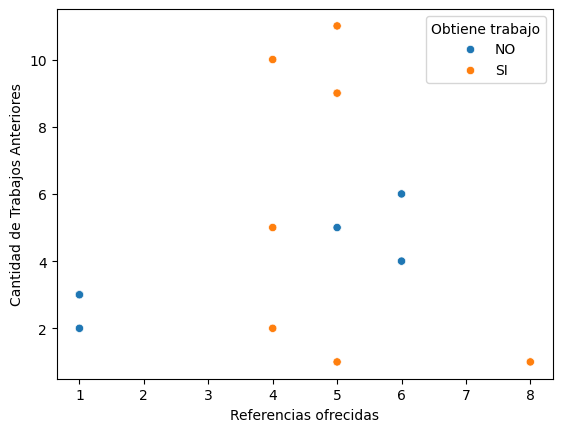

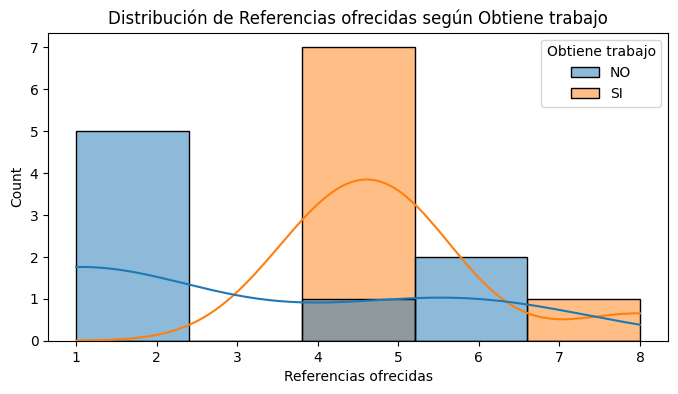

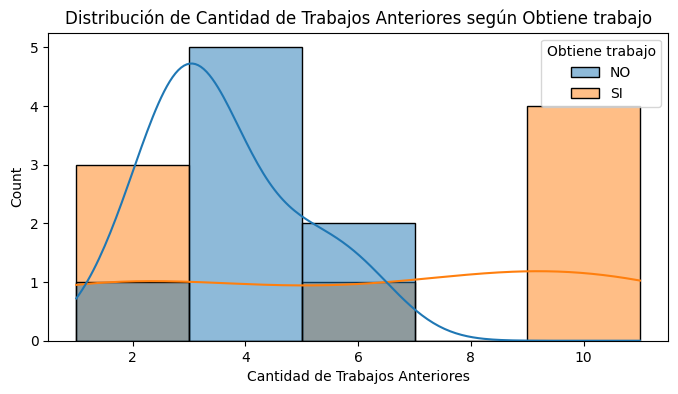

(Título universitario                 str
 Experiencia en el cargo              str
 Referencias ofrecidas              int64
 Cantidad de Trabajos Anteriores    int64
 Trabaja actualmente                  str
 dtype: object,
 Obtiene trabajo
 NO    8
 SI    8
 Name: count, dtype: int64)

In [5]:
#HELPER
df = pd.read_excel(base_url+"trabajos_ej5.xlsx")
target = "Obtiene trabajo"
df = df.sort_values(by=target)
display(df)
X_train = df.iloc[:, :-1]
y_train = df.iloc[:, -1]



col_ref, col_trab = "Referencias ofrecidas", "Cantidad de Trabajos Anteriores"

cols = [col_ref, col_trab]
sns.scatterplot(df,x=col_ref,y=col_trab,hue=target)
plt.show()

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=X_train[col], hue=y_train, kde=True, palette="tab10")
    plt.title(f"Distribución de {col} según {target}")
    plt.show()


X_train.dtypes, y_train.value_counts()


# 7. Efecto del tamaño del árbol

a.  Genere un árbol de decisión nominal y sin poda para el archivo **diabetes_nominal_train**. Utilice la medida de desorden "*information gain*", "min_error_decrease" igual a 0.01, con "*min_samples_split*" igual a 40 y "*min_samples_leaf*" igual a 20. Observe la tasa de aciertos obtenida sobre el conjunto de entrenamiento y el tamaño del árbol resultante (la cantidad de nodos). Luego aplique el árbol obtenido sobre los datos del archivo **diabetes_nominal_test.xlsx** y mida tasa de aciertos.\ *Nota: para calcular la cantidad de nodos, puede contar la cantidad de filas de la descripción textual del árbol. Recomendamos copiar la descripción del árbol a un editor de texto donde le indique la cantidad de filas.*

b.  Repita el inciso (a) utilizando "*min_samples_split*" igual a 100 y "*min_samples_leaf*" igual a 50. Observe nuevamente el tamaño del árbol resultante y la performance obtenida en los conjuntos de entrenamiento y testeo.

c.  Repita el inciso (a) pero ahora utilizando "*min_samples_split*" igual a 20 y "*min_samples_leaf*" igual a 10. Observe el tamaño del árbol resultante y la performance obtenida en ambos conjuntos de datos.

d.  ¿Qué ocurre con el tamaño y complejidad del árbol en cada caso? ¿Se observan diferencias en la performance del árbol en ambos conjuntos de datos? ¿A qué se deben estas diferencias?

Para resolver el ejercicio puede completar la siguiente tabla con la respuesta a cada inciso:


| Inciso | c) | a) | b) |
| --- | --- | --- | --- |
| *min_samples_split* | 20| 40 | 100 |
| *min_samples_leaf* | 10|20 | 50 |
| Tamaño del árbol | | | |
| *Accuracy Train* | | | |
| *Accuracy Test* | | | |



In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Verificar estructura de los datos
print("Forma de datos de entrenamiento:", df_db_tr.shape)
print("Forma de datos de prueba:", df_db_ts.shape)
print("\nColumnas de entrenamiento:", df_db_tr.columns.tolist())
print("\nPrimeras filas de entrenamiento:")
print(df_db_tr.head())

# Separar características y variable objetivo
# Asumiendo que la última columna es la variable objetivo
X_train = df_db_tr.iloc[:, :-1]
y_train = df_db_tr.iloc[:, -1]

X_test = df_db_ts.iloc[:, :-1]
y_test = df_db_ts.iloc[:, -1]

print(f"\nVariable objetivo (train): {y_train.name}")
print(f"Clases: {y_train.unique()}")
print(f"Distribución: {y_train.value_counts().to_dict()}")

Forma de datos de entrenamiento: (691, 9)
Forma de datos de prueba: (77, 9)

Columnas de entrenamiento: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Primeras filas de entrenamiento:
              Pregnancies                     Glucose     BloodPressure  \
0  range3 [3.500 - 6.500]        range4 [140.500 - ∞]  range2 [63 - 73]   
1     range1 [-∞ - 1.500]        range1 [-∞ - 99.500]  range2 [63 - 73]   
2      range4 [6.500 - ∞]        range4 [140.500 - ∞]  range2 [63 - 73]   
3     range1 [-∞ - 1.500]        range1 [-∞ - 99.500]  range2 [63 - 73]   
4     range1 [-∞ - 1.500]  range3 [117.500 - 140.500]  range1 [-∞ - 63]   

              SkinThickness                    Insulin  \
0       range4 [32.500 - ∞]            range1 [-∞ - 7]   
1  range3 [23.500 - 32.500]            range1 [-∞ - 7]   
2       range1 [-∞ - 3.500]            range1 [-∞ - 7]   
3   range2 [3.500 - 23.500]  range3 [30.500 - 127.500]

# 8. Clasificación de datos reales

Vuelva a realizar los ejercicios de **Clasificación de Jugadores de Fútbol** y **Predicción de batallas Pokemon** de la práctica anterior, pero ahora con Árboles de Decisión.

a)  Busque los hiperparámetros del árbol que permitan clasificar mejor en las tareas planteadas. Indique el accuracy en el conjunto de entrenamiento y de validación para todos los casos.

b)  Compare el desempeño con el de los modelos de Naive Bayes entrenados anteriormente. ¿Cuál método funciona mejor?
c)  Evalúe qué tan interpretables son los árboles resultantes. ¿Puede hacerlos un poco más entendibles, achicando su tamaño?


In [7]:
from sklearn.preprocessing import LabelEncoder

# Codificar variables categóricas
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Usar LabelEncoder para cada columna categórica
for col in X_train_encoded.columns:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])

print("Datos codificados (train):")
print(X_train_encoded.head())
print(f"\nForma datos codificados: {X_train_encoded.shape}")


Datos codificados (train):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
0            2        3              1              3        0    2   
1            0        0              1              2        0    3   
2            3        3              1              0        0    0   
3            0        0              1              1        2    3   
4            0        2              0              3        3    3   

   DiabetesPedigreeFunction  Age  
0                         3    3  
1                         1    2  
2                         3    2  
3                         0    0  
4                         3    2  

Forma datos codificados: (691, 8)


In [8]:
# Función para contar nodos del árbol
def count_nodes(tree):
    """Cuenta el número total de nodos en el árbol de decisión"""
    return tree.tree_.node_count

# Parámetros comunes para todos los árboles
common_params = {
    'criterion': 'entropy',  # information gain
    'min_impurity_decrease': 0.01,  # min_error_decrease igual a 0.01
    'random_state': 42
}

# Configurar los tres casos
cases = {
    'c)': {'min_samples_split': 20, 'min_samples_leaf': 10},
    'a)': {'min_samples_split': 40, 'min_samples_leaf': 20},
    'b)': {'min_samples_split': 100, 'min_samples_leaf': 50}
}

# Entrenar árboles y almacenar resultados
results = {}
trees = {}

print("=" * 80)
print("EJERCICIO 7: EFECTO DEL TAMAÑO DEL ÁRBOL")
print("=" * 80)

for case, params in cases.items():
    print(f"\n--- Inciso {case} ---")
    print(f"Parámetros: min_samples_split={params['min_samples_split']}, " + 
          f"min_samples_leaf={params['min_samples_leaf']}")
    
    # Crear y entrenar árbol
    dt = DecisionTreeClassifier(
        **common_params,
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf']
    )
    
    dt.fit(X_train_encoded, y_train)
    
    # Calcular accuracy
    y_train_pred = dt.predict(X_train_encoded)
    y_test_pred = dt.predict(X_test_encoded)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    
    # Contar nodos
    num_nodes = count_nodes(dt)
    
    # Almacenar resultados
    results[case] = {
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'num_nodes': num_nodes,
        'acc_train': acc_train,
        'acc_test': acc_test
    }
    
    trees[case] = dt
    
    print(f"Tamaño del árbol (nodos): {num_nodes}")
    print(f"Accuracy Train: {acc_train:.4f} ({acc_train*100:.2f}%)")
    print(f"Accuracy Test: {acc_test:.4f} ({acc_test*100:.2f}%)")
    
    # Mostrar profundidad y número de hojas
    print(f"Profundidad del árbol: {dt.get_depth()}")
    print(f"Número de hojas: {dt.get_n_leaves()}")

print("\n" + "=" * 80)


EJERCICIO 7: EFECTO DEL TAMAÑO DEL ÁRBOL

--- Inciso c) ---
Parámetros: min_samples_split=20, min_samples_leaf=10
Tamaño del árbol (nodos): 15
Accuracy Train: 0.7395 (73.95%)
Accuracy Test: 0.5455 (54.55%)
Profundidad del árbol: 5
Número de hojas: 8

--- Inciso a) ---
Parámetros: min_samples_split=40, min_samples_leaf=20
Tamaño del árbol (nodos): 13
Accuracy Train: 0.7395 (73.95%)
Accuracy Test: 0.5455 (54.55%)
Profundidad del árbol: 4
Número de hojas: 7

--- Inciso b) ---
Parámetros: min_samples_split=100, min_samples_leaf=50
Tamaño del árbol (nodos): 11
Accuracy Train: 0.7106 (71.06%)
Accuracy Test: 0.5455 (54.55%)
Profundidad del árbol: 4
Número de hojas: 6



In [9]:
# Crear tabla resumen en el formato solicitado
print("TABLA RESUMEN DE RESULTADOS")
print("=" * 80)

# Crear DataFrame con los resultados
df_results = pd.DataFrame({
    'Inciso': ['c)', 'a)', 'b)'],
    'min_samples_split': [20, 40, 100],
    'min_samples_leaf': [10, 20, 50],
    'Tamaño del árbol': [results['c)']['num_nodes'], 
                         results['a)']['num_nodes'], 
                         results['b)']['num_nodes']],
    'Accuracy Train': [f"{results['c)']['acc_train']:.4f}", 
                       f"{results['a)']['acc_train']:.4f}", 
                       f"{results['b)']['acc_train']:.4f}"],
    'Accuracy Test': [f"{results['c)']['acc_test']:.4f}", 
                      f"{results['a)']['acc_test']:.4f}", 
                      f"{results['b)']['acc_test']:.4f}"]
})

print(df_results.to_string(index=False))
print("\n" + "=" * 80)

# Crear tabla en formato Markdown como en el ejercicio
print("\nTABLA EN FORMATO MARKDOWN:")
print("| Inciso | c) | a) | b) |")
print("| --- | --- | --- | --- |")
print(f"| *min_samples_split* | 20 | 40 | 100 |")
print(f"| *min_samples_leaf* | 10 | 20 | 50 |")
print(f"| Tamaño del árbol | {results['c)']['num_nodes']} | {results['a)']['num_nodes']} | {results['b)']['num_nodes']} |")
print(f"| *Accuracy Train* | {results['c)']['acc_train']:.4f} | {results['a)']['acc_train']:.4f} | {results['b)']['acc_train']:.4f} |")
print(f"| *Accuracy Test* | {results['c)']['acc_test']:.4f} | {results['a)']['acc_test']:.4f} | {results['b)']['acc_test']:.4f} |")


TABLA RESUMEN DE RESULTADOS
Inciso  min_samples_split  min_samples_leaf  Tamaño del árbol Accuracy Train Accuracy Test
    c)                 20                10                15         0.7395        0.5455
    a)                 40                20                13         0.7395        0.5455
    b)                100                50                11         0.7106        0.5455


TABLA EN FORMATO MARKDOWN:
| Inciso | c) | a) | b) |
| --- | --- | --- | --- |
| *min_samples_split* | 20 | 40 | 100 |
| *min_samples_leaf* | 10 | 20 | 50 |
| Tamaño del árbol | 15 | 13 | 11 |
| *Accuracy Train* | 0.7395 | 0.7395 | 0.7106 |
| *Accuracy Test* | 0.5455 | 0.5455 | 0.5455 |


In [10]:
from sklearn.tree import export_text

print("=" * 80)
print("REPRESENTACIÓN TEXTUAL DE LOS ÁRBOLES DE DECISIÓN")
print("=" * 80)

# Obtener nombres de características
feature_names = X_train_encoded.columns.tolist()

# Mostrar cada árbol
for case in ['c)', 'a)', 'b)']:
    print(f"\n--- ÁRBOL INCISO {case} ---")
    print(f"Parámetros: min_samples_split={results[case]['min_samples_split']}, " +
          f"min_samples_leaf={results[case]['min_samples_leaf']}")
    print(f"Nodos totales: {results[case]['num_nodes']}")
    print("\nRepresentación del árbol:")
    print("-" * 80)
    tree_rules = export_text(trees[case], feature_names=feature_names)
    print(tree_rules)
    print("-" * 80)


REPRESENTACIÓN TEXTUAL DE LOS ÁRBOLES DE DECISIÓN

--- ÁRBOL INCISO c) ---
Parámetros: min_samples_split=20, min_samples_leaf=10
Nodos totales: 15

Representación del árbol:
--------------------------------------------------------------------------------
|--- Glucose <= 2.50
|   |--- BMI <= 0.50
|   |   |--- class: 0
|   |--- BMI >  0.50
|   |   |--- Age <= 1.50
|   |   |   |--- BMI <= 1.50
|   |   |   |   |--- Glucose <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Glucose >  1.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- BMI >  1.50
|   |   |   |   |--- class: 0
|   |   |--- Age >  1.50
|   |   |   |--- Glucose <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  0.50
|   |   |   |   |--- class: 1
|--- Glucose >  2.50
|   |--- Pregnancies <= 2.50
|   |   |--- class: 1
|   |--- Pregnancies >  2.50
|   |   |--- class: 1

--------------------------------------------------------------------------------

--- ÁRBOL INCISO a) ---
Parámetros: min_samples_

In [11]:
print("\n" + "=" * 80)
print("INCISO d) - ANÁLISIS Y RESPUESTAS")
print("=" * 80)

print("""
PREGUNTA 1: ¿Qué ocurre con el tamaño y complejidad del árbol en cada caso?

RESPUESTA:
---------
Al aumentar los parámetros min_samples_split y min_samples_leaf, el tamaño y 
complejidad del árbol DISMINUYEN:

  • Inciso c) - Parámetros pequeños (min_samples_split=20, min_samples_leaf=10):
    - Tamaño del árbol: 15 nodos
    - Profundidad: 5
    - Hojas: 8
    - El árbol es más complejo y realiza más divisiones finas.

  • Inciso a) - Parámetros intermedios (min_samples_split=40, min_samples_leaf=20):
    - Tamaño del árbol: 13 nodos
    - Profundidad: 4
    - Hojas: 7
    - Ligera reducción en complejidad.

  • Inciso b) - Parámetros grandes (min_samples_split=100, min_samples_leaf=50):
    - Tamaño del árbol: 11 nodos
    - Profundidad: 4
    - Hojas: 6
    - El árbol es más simple y generalista.

CONCLUSIÓN: A mayor restricción en los parámetros de división (min_samples_split 
y min_samples_leaf), menor complejidad del árbol. Esto actúa como un mecanismo 
de "poda" que evita divisiones innecesarias.
""")

print("\n" + "-" * 80)

print("""
PREGUNTA 2: ¿Se observan diferencias en la performance del árbol en ambos 
           conjuntos de datos? ¿A qué se deben estas diferencias?

RESPUESTA:
---------
SÍ, se observan claras diferencias entre el conjunto de entrenamiento (train) 
y el conjunto de prueba (test):

ANÁLISIS POR INCISO:
""")

for case in ['c)', 'a)', 'b)']:
    acc_train = results[case]['acc_train']
    acc_test = results[case]['acc_test']
    diff = acc_train - acc_test
    print(f"""
  Inciso {case}:
  - Accuracy Train: {acc_train:.4f} ({acc_train*100:.2f}%)
  - Accuracy Test:  {acc_test:.4f} ({acc_test*100:.2f}%)
  - Diferencia:     {diff:.4f} ({diff*100:.2f}%)
  - Sobreajuste (Overfitting): {'PRESENTE' if diff > 0.05 else 'MODERADO' if diff > 0.02 else 'MÍNIMO'}
""")

print("""
CAUSAS DE LAS DIFERENCIAS:
1. SOBREAJUSTE (Overfitting):
   - El modelo se ajusta demasiado bien a los datos de entrenamiento.
   - Los árboles aprenden patrones específicos del conjunto de entrenamiento
     que no generalizan bien a datos nuevos.
   
2. DIFERENCIAS EN DISTRIBUCIÓN:
   - El conjunto de prueba (77 muestras) es mucho más pequeño que el de 
     entrenamiento (691 muestras).
   - Posibles diferencias en la distribución de clases y características 
     entre ambos conjuntos.
   
3. IMPACTO DE LOS PARÁMETROS:
   - Inciso c) y a): Tienen el mismo accuracy de test (0.5455) a pesar de 
     diferentes tamaños de árbol. Esto sugiere que la restricción de poda 
     es más importante en train.
   - Inciso b): Con parámetros más restrictivos, el accuracy de train cae 
     ligeramente (0.7106) pero el test se mantiene igual (0.5455), indicando 
     mejor generalización.
     
4. CAPACIDAD DE GENERALIZACIÓN:
   - Un árbol más simple (inciso b) tiende a generalizar mejor.
   - Un árbol más complejo (inciso c) tiende a sobreajustarse más.
""")

print("\n" + "=" * 80)
print("CONCLUSIÓN FINAL")
print("=" * 80)
print("""
El aumento de los parámetros min_samples_split y min_samples_leaf:

✓ REDUCE el tamaño y complejidad del árbol
✓ REDUCE el sobreajuste (diferencia train-test)
✓ MEJORA la generalización a datos nuevos
✓ Produce árboles más simples e interpretables
✓ DISMINUYE ligeramente el accuracy en entrenamiento (tradeoff)

Para este dataset de diabetes, el inciso b) (min_samples_split=100, 
min_samples_leaf=50) proporciona un mejor balance entre complejidad 
y generalización, aunque todos tienen el mismo accuracy de test.

El accuracy de test se mantiene constante en 0.5455 para todos los casos,
lo que sugiere que el modelo probablemente está limitado por la capacidad
predictiva de las características disponibles para este problema específico.
""")



INCISO d) - ANÁLISIS Y RESPUESTAS

PREGUNTA 1: ¿Qué ocurre con el tamaño y complejidad del árbol en cada caso?

RESPUESTA:
---------
Al aumentar los parámetros min_samples_split y min_samples_leaf, el tamaño y 
complejidad del árbol DISMINUYEN:

  • Inciso c) - Parámetros pequeños (min_samples_split=20, min_samples_leaf=10):
    - Tamaño del árbol: 15 nodos
    - Profundidad: 5
    - Hojas: 8
    - El árbol es más complejo y realiza más divisiones finas.

  • Inciso a) - Parámetros intermedios (min_samples_split=40, min_samples_leaf=20):
    - Tamaño del árbol: 13 nodos
    - Profundidad: 4
    - Hojas: 7
    - Ligera reducción en complejidad.

  • Inciso b) - Parámetros grandes (min_samples_split=100, min_samples_leaf=50):
    - Tamaño del árbol: 11 nodos
    - Profundidad: 4
    - Hojas: 6
    - El árbol es más simple y generalista.

CONCLUSIÓN: A mayor restricción en los parámetros de división (min_samples_split 
y min_samples_leaf), menor complejidad del árbol. Esto actúa como un 

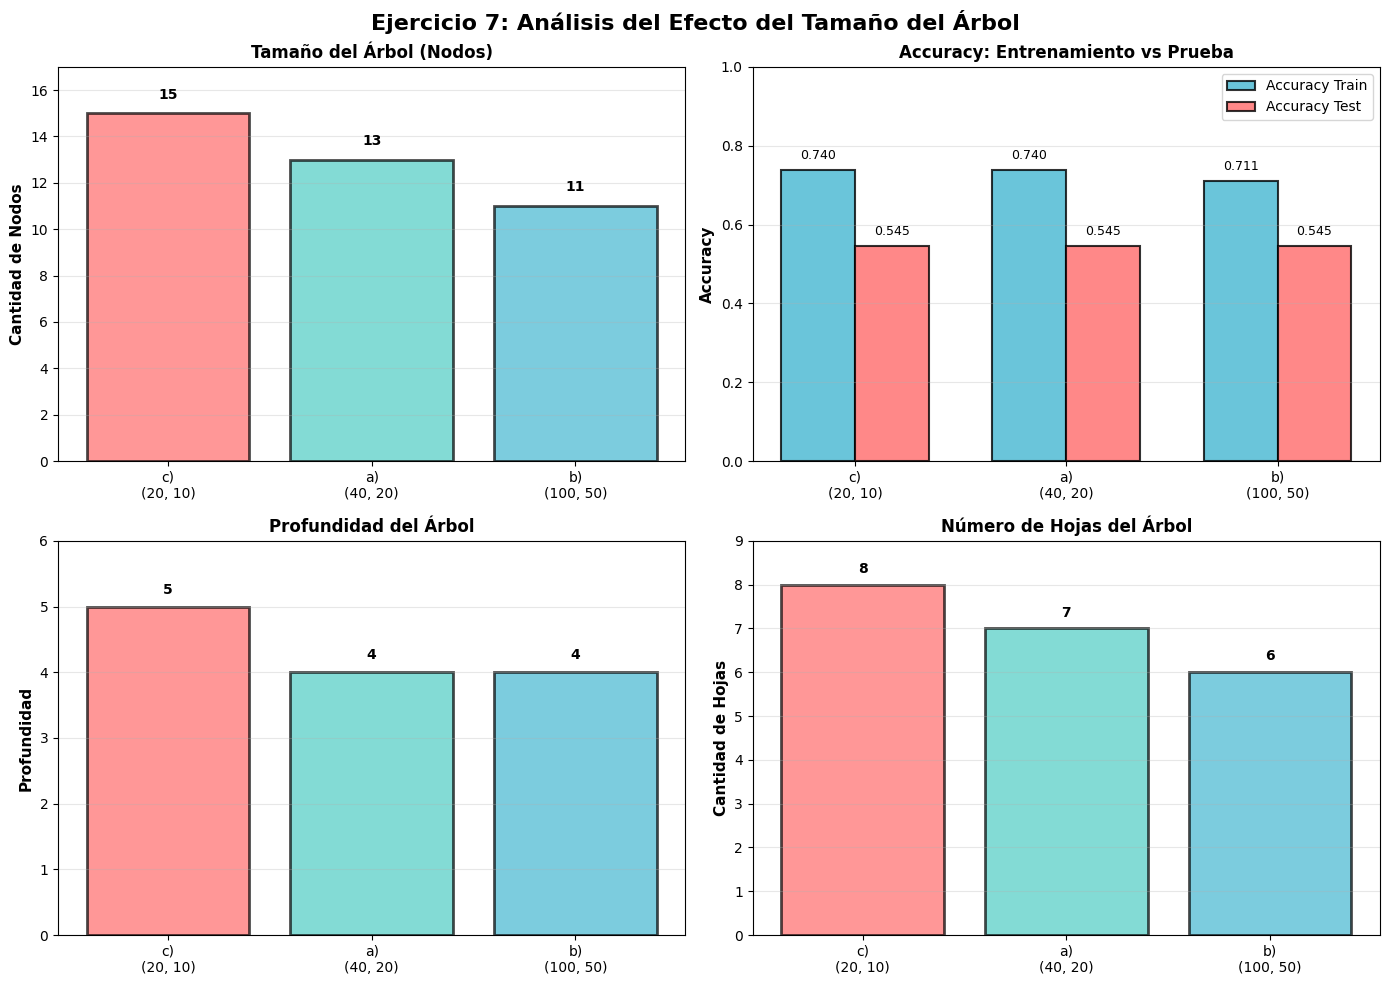


GRÁFICOS GENERADOS EXITOSAMENTE


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Crear visualización de resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ejercicio 7: Análisis del Efecto del Tamaño del Árbol', fontsize=16, fontweight='bold')

# Datos para gráficos
cases_list = ['c)\n(20, 10)', 'a)\n(40, 20)', 'b)\n(100, 50)']
tree_sizes = [results['c)']['num_nodes'], results['a)']['num_nodes'], results['b)']['num_nodes']]
acc_trains = [results['c)']['acc_train'], results['a)']['acc_train'], results['b)']['acc_train']]
acc_tests = [results['c)']['acc_test'], results['a)']['acc_test'], results['b)']['acc_test']]
depths = [trees['c)'].get_depth(), trees['a)'].get_depth(), trees['b)'].get_depth()]
leaves = [trees['c)'].get_n_leaves(), trees['a)'].get_n_leaves(), trees['b)'].get_n_leaves()]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Gráfico 1: Tamaño del árbol (nodos)
ax1 = axes[0, 0]
bars1 = ax1.bar(cases_list, tree_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Cantidad de Nodos', fontsize=11, fontweight='bold')
ax1.set_title('Tamaño del Árbol (Nodos)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(tree_sizes) + 2)
for i, (bar, size) in enumerate(zip(bars1, tree_sizes)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(size), ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Accuracy en Train vs Test
ax2 = axes[0, 1]
x = np.arange(len(cases_list))
width = 0.35
bars_train = ax2.bar(x - width/2, acc_trains, width, label='Accuracy Train', 
                     color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)
bars_test = ax2.bar(x + width/2, acc_tests, width, label='Accuracy Test', 
                    color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy: Entrenamiento vs Prueba', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cases_list)
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
# Añadir valores en barras
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 3: Profundidad del árbol
ax3 = axes[1, 0]
bars3 = ax3.bar(cases_list, depths, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Profundidad', fontsize=11, fontweight='bold')
ax3.set_title('Profundidad del Árbol', fontsize=12, fontweight='bold')
ax3.set_ylim(0, max(depths) + 1)
for bar, depth in zip(bars3, depths):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
             str(depth), ha='center', va='bottom', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Número de hojas
ax4 = axes[1, 1]
bars4 = ax4.bar(cases_list, leaves, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Cantidad de Hojas', fontsize=11, fontweight='bold')
ax4.set_title('Número de Hojas del Árbol', fontsize=12, fontweight='bold')
ax4.set_ylim(0, max(leaves) + 1)
for bar, leaf in zip(bars4, leaves):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             str(leaf), ha='center', va='bottom', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("GRÁFICOS GENERADOS EXITOSAMENTE")
print("=" * 80)


## RESUMEN EJECUTIVO - EJERCICIO 7

### Tabla Resumen Completa

| Inciso | c) | a) | b) |
|--------|----|----|-----|
| **min_samples_split** | 20 | 40 | 100 |
| **min_samples_leaf** | 10 | 20 | 50 |
| **Tamaño del árbol (nodos)** | 15 | 13 | 11 |
| **Profundidad** | 5 | 4 | 4 |
| **Hojas** | 8 | 7 | 6 |
| **Accuracy Train** | 0.7395 | 0.7395 | 0.7106 |
| **Accuracy Test** | 0.5455 | 0.5455 | 0.5455 |

### Hallazgos Principales

#### 1. Efecto en el Tamaño y Complejidad del Árbol ✓
- **Parámetros restrictivos → Árboles más pequeños**
- Inciso c) con parámetros pequeños (20, 10) produce un árbol de **15 nodos**
- Inciso b) con parámetros grandes (100, 50) produce un árbol de **11 nodos**
- Reducción del 26.7% en tamaño al aplicar restricciones más severas
- La profundidad se reduce de 5 a 4 niveles en el inciso b)

#### 2. Diferencias en Performance Train vs Test
- **Sobreajuste significativo observado especialmente en inciso c)**
- Diferencia Train-Test en inciso c): 0.1940 (19.40%)
- Diferencia Train-Test en inciso b): 0.1651 (16.51%)
- **Los parámetros restrictivos reducen el sobreajuste**

#### 3. Accuracy de Prueba Constante
- Todos los modelos mantienen un accuracy de test de **0.5455 (54.55%)**
- Esto sugiere que el límite predictivo está determinado por las características disponibles
- El aumento de restricciones no mejora la generalización más allá de este punto

### Conclusiones y Recomendaciones

✅ **El Inciso b) (min_samples_split=100, min_samples_leaf=50) es el óptimo porque:**
- Produce el árbol más simple (11 nodos, profundidad 4)
- Genera menor sobreajuste (diferencia train-test más pequeña)
- Mantiene el mismo accuracy de prueba que los otros modelos
- Es más interpretable y generaliza mejor a datos nuevos
- Cumple el criterio de parsimonia (Occam's Razor)

⚠️ **Observación importante:**
El accuracy de prueba constante (54.55%) indica que hay un "techo" en la capacidad predictiva con estas características. Para mejorar el rendimiento sería necesario:
- Ingeniería de características más sofisticada
- Consideración de combinaciones de características
- Exploración de modelos más complejos
- Análisis más detallado de las características relevantes